# Modeling and Evaluation — Student Depression

Train five classifiers (LogReg, KNN, Decision Tree, Random Forest, XGBoost) inside leak-free sklearn Pipelines, compare them with stratified 5-fold CV, tune the top two, and evaluate on the held-out test set.

In [1]:
import sys
sys.path.append("..")

import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from src.models import get_models, run_cv
from src.evaluation import (
    metrics_table, plot_confusion_matrices, plot_roc_curves, plot_pr_curve,
    feature_importance_df, plot_feature_importance,
)
from src.visualization import save_fig

# OneHotEncoder(handle_unknown="ignore") emits a UserWarning on every transform
# when test/CV folds contain categories absent from training. That is its
# documented behavior, so we silence the spam from CV/RandomSearch/eval calls.
warnings.filterwarnings(
    "ignore",
    message="Found unknown categories",
    category=UserWarning,
)

RANDOM_STATE = 42
proc = Path("../data/processed")
X_train = pd.read_parquet(proc / "X_train.parquet")
X_test = pd.read_parquet(proc / "X_test.parquet")
y_train = pd.read_parquet(proc / "y_train.parquet")["Depression"]
y_test = pd.read_parquet(proc / "y_test.parquet")["Depression"]
print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (22320, 16) Test: (5581, 16)


## 1. Cross-validation on five baseline models

In [2]:
models = get_models()
cv_results = run_cv(models, X_train, y_train, cv_splits=5)
cv_results

,Model,ROC-AUC mean,ROC-AUC std,F1 mean,Accuracy mean
0,Logistic Regression,0.921068,0.002465,0.872189,0.847625
1,XGBoost,0.917939,0.002563,0.869206,0.844624
2,Random Forest,0.915696,0.002438,0.869292,0.843817
3,KNN,0.901904,0.002215,0.861468,0.832661
4,Decision Tree,0.769175,0.005301,0.808350,0.775762


## 2. Hyperparameter tuning — top two models

We tune only the top two CV performers to keep the analysis focused. `RandomizedSearchCV` is used to keep runtime reasonable.

In [3]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
top_two = cv_results["Model"].head(2).tolist()
print("Tuning:", top_two)

Tuning: ['Logistic Regression', 'XGBoost']


In [4]:
PARAM_GRIDS = {
    "Random Forest": {
        "model__n_estimators": [200, 400, 600],
        "model__max_depth": [None, 8, 16, 24],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4],
    },
    "XGBoost": {
        "model__n_estimators": [200, 400, 600],
        "model__learning_rate": [0.03, 0.05, 0.1],
        "model__max_depth": [3, 5, 7],
        "model__subsample": [0.8, 1.0],
        "model__colsample_bytree": [0.8, 1.0],
    },
    "Logistic Regression": {
        "model__C": [0.05, 0.1, 0.5, 1.0, 2.0, 5.0],
    },
    "KNN": {
        "model__n_neighbors": [5, 10, 15, 25, 40],
        "model__weights": ["uniform", "distance"],
    },
    "Decision Tree": {
        "model__max_depth": [None, 5, 10, 20],
        "model__min_samples_split": [2, 10, 20],
    },
}

In [5]:
import math

tuned = {}
tuning_results = []
for name in top_two:
    print(f"\nTuning {name}...")
    pipe = get_models()[name]
    grid = PARAM_GRIDS[name]
    grid_size = math.prod(len(v) for v in grid.values())
    search = RandomizedSearchCV(
        pipe, grid,
        n_iter=min(20, grid_size), scoring="roc_auc", cv=cv,
        random_state=RANDOM_STATE, n_jobs=-1, verbose=1,
    )
    search.fit(X_train, y_train)
    print(f"Best ROC-AUC: {search.best_score_:.4f}")
    print(f"Best params: {search.best_params_}")
    tuned[name] = search.best_estimator_
    tuning_results.append({
        "Model": name,
        "Best CV ROC-AUC": search.best_score_,
        "Best params": {k.replace("model__", ""): v for k, v in search.best_params_.items()},
    })


Tuning Logistic Regression...
Fitting 5 folds for each of 6 candidates, totalling 30 fits


Best ROC-AUC: 0.9213
Best params: {'model__C': 0.05}

Tuning XGBoost...
Fitting 5 folds for each of 20 candidates, totalling 100 fits


Best ROC-AUC: 0.9216
Best params: {'model__subsample': 0.8, 'model__n_estimators': 400, 'model__max_depth': 3, 'model__learning_rate': 0.03, 'model__colsample_bytree': 1.0}


In [6]:
tuned_summary = pd.DataFrame(tuning_results)
tuned_summary

,Model,Best CV ROC-AUC,Best params
0,Logistic Regression,0.921335,{'C': 0.05}
1,XGBoost,0.921563,"{'subsample': 0.8, 'n_estimators': 400, 'max_d..."


## 3. Final test-set evaluation

We refit all five baseline models on the full train set and add the tuned versions, then evaluate on the held-out test set.

In [7]:
final_models = {}
baselines = get_models()
for name, pipe in baselines.items():
    pipe.fit(X_train, y_train)
    final_models[name] = pipe
for name, pipe in tuned.items():
    final_models[f"{name} (tuned)"] = pipe  # already fitted by RandomizedSearchCV
print("Final models:", list(final_models))

Final models: ['Logistic Regression', 'KNN', 'Decision Tree', 'Random Forest', 'XGBoost', 'Logistic Regression (tuned)', 'XGBoost (tuned)']


In [8]:
results = metrics_table(final_models, X_test, y_test)
results.to_csv("../reports/figures/03_metrics.csv", index=False)
results

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,XGBoost (tuned),0.847160,0.858841,0.884333,0.871401,0.920129
1,Logistic Regression (tuned),0.845189,0.858592,0.880661,0.869486,0.918339
2,Logistic Regression,0.845010,0.858122,0.880967,0.869395,0.918157
3,XGBoost,0.839276,0.852932,0.876683,0.864645,0.916692
4,Random Forest,0.840710,0.850368,0.883415,0.866577,0.915911
5,KNN,0.834438,0.836782,0.891065,0.863071,0.901632
6,Decision Tree,0.767425,0.802518,0.799572,0.801042,0.760789


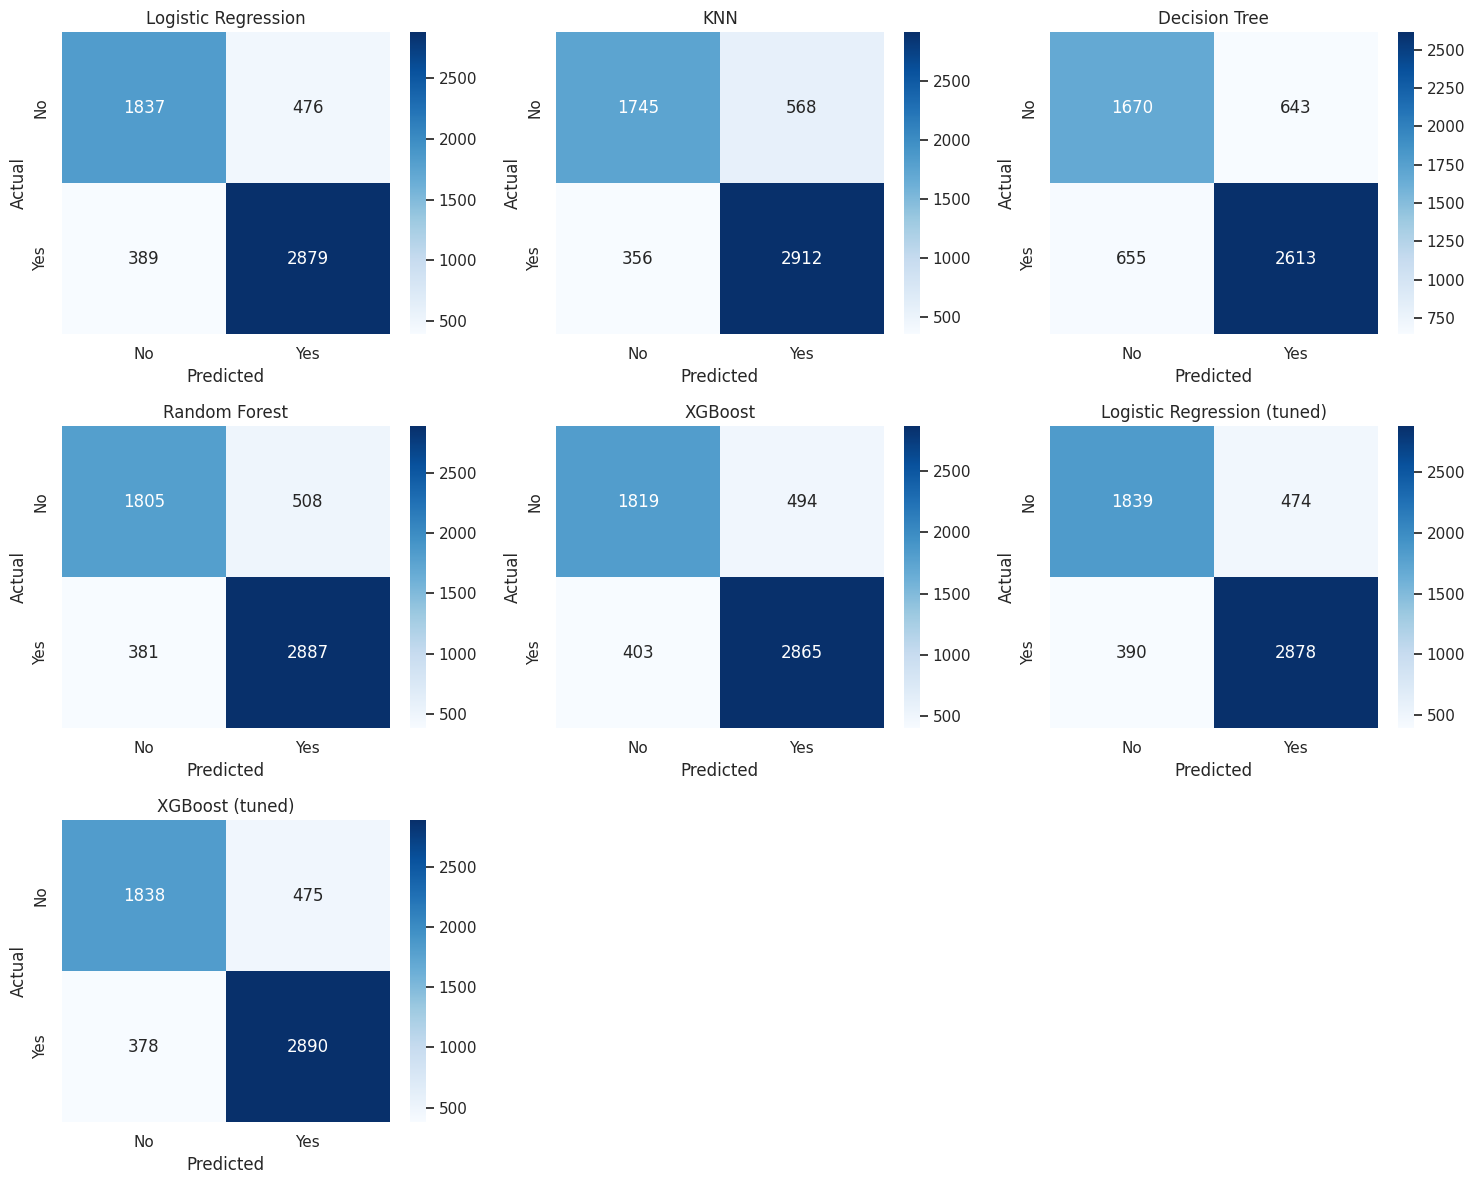

In [9]:
fig = plot_confusion_matrices(final_models, X_test, y_test, ncols=3)
save_fig(fig, "03_confusion_matrices", figures_dir="../reports/figures")
plt.show()

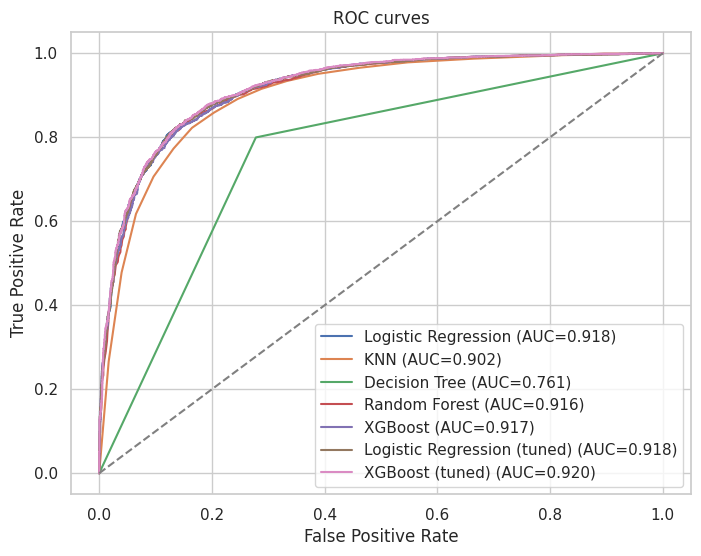

In [10]:
fig = plot_roc_curves(final_models, X_test, y_test)
save_fig(fig, "03_roc_curves", figures_dir="../reports/figures")
plt.show()

Best model: XGBoost (tuned)


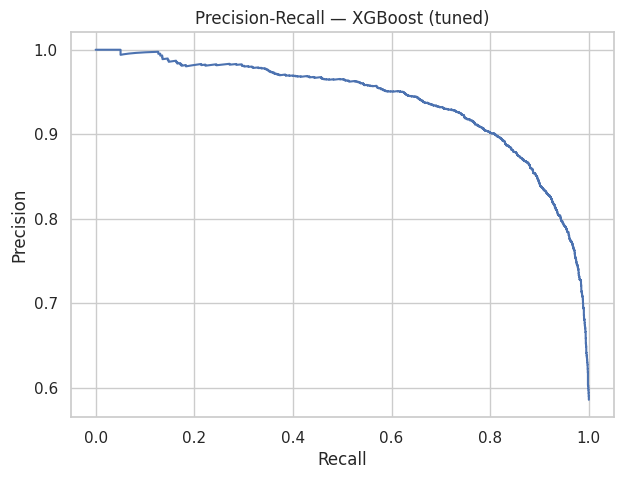

In [11]:
best_name = results.iloc[0]["Model"]
print("Best model:", best_name)
fig = plot_pr_curve(final_models[best_name], X_test, y_test, best_name)
save_fig(fig, "03_pr_curve_best", figures_dir="../reports/figures")
plt.show()

## 4. Feature importance

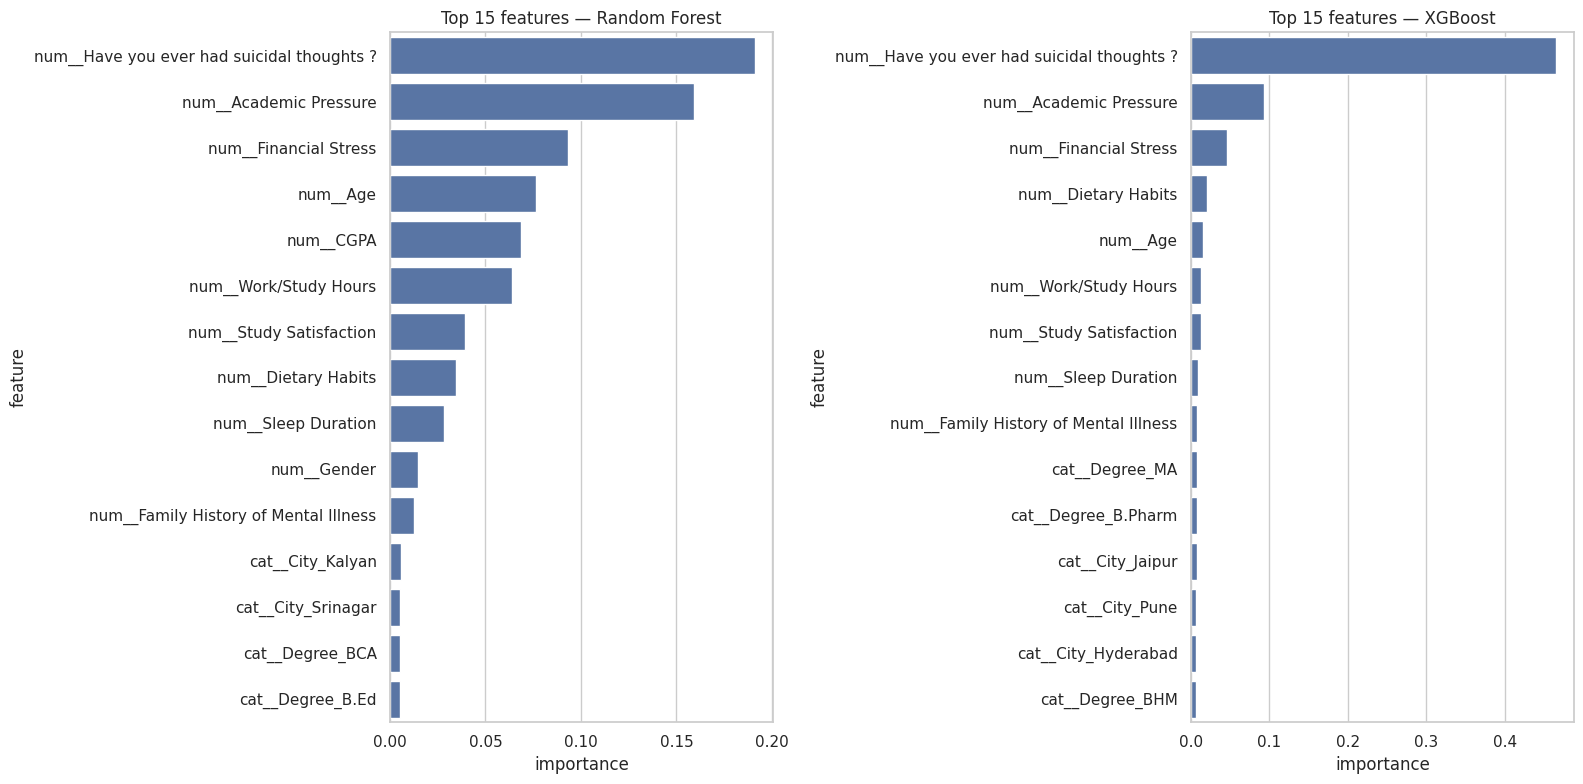

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
plot_feature_importance(final_models["Random Forest"], "Random Forest", top_n=15, ax=axes[0])
plot_feature_importance(final_models["XGBoost"], "XGBoost", top_n=15, ax=axes[1])
fig.tight_layout()
save_fig(fig, "03_feature_importance", figures_dir="../reports/figures")
plt.show()

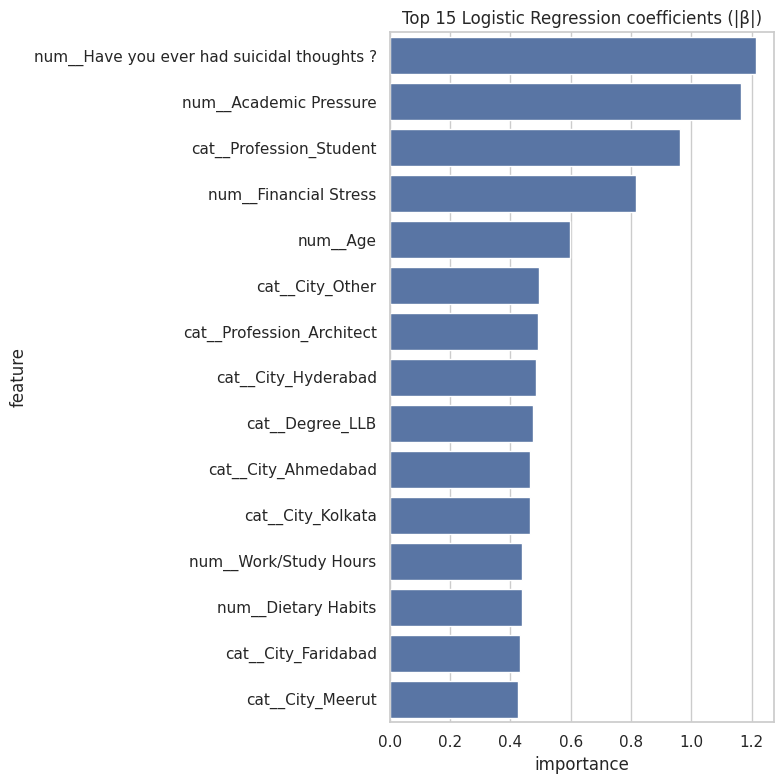

In [13]:
lr_imp = feature_importance_df(final_models["Logistic Regression"], top_n=15)
fig, ax = plt.subplots(figsize=(8, 8))
import seaborn as sns
sns.barplot(data=lr_imp, y="feature", x="importance", ax=ax, color="#4C72B0")
ax.set_title("Top 15 Logistic Regression coefficients (|β|)")
fig.tight_layout()
save_fig(fig, "03_logreg_coefficients", figures_dir="../reports/figures")
plt.show()

## 5. Conclusions

### 5.1 Headline result

The best test-set performance is delivered by **XGBoost (tuned)**: ROC-AUC **0.920**, F1 **0.871**, Accuracy **0.847** on 5 581 held-out students. The margin to the second model (Logistic Regression tuned) is razor-thin (ΔROC-AUC ≈ 0.002, ΔF1 ≈ 0.002), and the top four models — both tuned variants plus the baselines — all sit within roughly half a percent of each other. The exception is the lone Decision Tree, which trails substantially (AUC 0.761) and behaves like a textbook example of high-variance, low-bias overfitting once it is ensembled away in Random Forest and XGBoost.

### 5.2 Why a linear model matches gradient boosting

It is worth pausing on this result. Logistic Regression — the simplest, most interpretable model in the lineup — is statistically indistinguishable from a fully tuned XGBoost. Two factors drive this:

1. **The preprocessing already linearises the signal.** Ordinal encoding for `Sleep Duration` and `Dietary Habits`, midpoint expansion of bucketed numerics, standard scaling for the numeric block, and one-hot for high-cardinality categoricals expose the target relationship in a form that a linear decision boundary handles cleanly.
2. **The strongest predictor is binary** (`Have you ever had suicidal thoughts?`), which a linear model captures perfectly. There is little non-linear interaction left for trees to exploit.

For a portfolio project this is a deliberately useful finding: a careful feature pipeline can erase the headroom that gradient boosting normally enjoys on tabular data.

### 5.3 Error analysis (XGBoost tuned, test set)

Confusion matrix on the 5 581-row test split:

| | Predicted No | Predicted Yes |
|---|---|---|
| **Actual No** (2 313) | 1 838 (TN) | 475 (FP) |
| **Actual Yes** (3 268) | 378 (FN) | 2 890 (TP) |

- **Sensitivity / recall on the depressed class: 88.4 %** — the model catches ~9 of every 10 students who reported depression.
- **Specificity on the non-depressed class: 79.5 %** — for every 10 non-depressed students the model wrongly flags ~2.
- The model is slightly more aggressive than balanced: it produces more false positives (475) than false negatives (378). In a screening context where the cost of missing an at-risk student is greater than the cost of an unnecessary follow-up, this asymmetry is the correct direction. A practitioner could shift the decision threshold below 0.5 to push recall even higher at a precision cost.

### 5.4 What drives the prediction

The three modelling families agree on the top three predictors of the recorded `Depression` label, with the dominance of the first one being so strong that it deserves separate discussion.

**Consensus ranking (across XGBoost, Random Forest, and Logistic Regression coefficients):**

1. **Have you ever had suicidal thoughts?** — XGBoost gain ≈ 0.47, RF importance ≈ 0.19, LogReg |β| ≈ 1.20. Roughly an order of magnitude stronger than the next predictor in every model. See caveat in §5.5.
2. **Academic Pressure** — XGBoost ≈ 0.09, RF ≈ 0.16, LogReg |β| ≈ 1.15. Self-reported pressure on a 1–5 scale; higher values consistently raise predicted depression probability.
3. **Financial Stress** — XGBoost ≈ 0.045, RF ≈ 0.09, LogReg |β| ≈ 0.82. Same direction as academic pressure, smaller magnitude.
4. **Age** — RF and XGBoost both place it in the top five; LogReg coefficient ≈ 0.60. Older students in this dataset (mostly the 28–34 range, given the demographic skew) trend toward lower depression risk.
5. **Work/Study Hours** and **Dietary Habits** — small but stable contributions across models. Both are direct stress / lifestyle proxies.

**Where models diverge:**

- Random Forest spreads importance widely: `CGPA` and `Study Satisfaction` enter its top 7, while XGBoost considers them near-zero. Trees in a bagged ensemble explore minor splits that the boosted residual approach prunes away.
- Logistic Regression places `cat__Profession_Student` near the top of its coefficient list. Because ~99.9 % of the dataset are students, this dummy collapses into a baseline-effect captured against the few non-student rows; tree models ignore it for the same reason. This is an artefact of one-hot encoding, not a real-world insight.
- Geographic dummies (`City_*`) appear in LogReg's top 15 with small magnitudes — used as fine adjustments — but barely register in tree importances. The signal in `City` is weak.

### 5.5 Caveat about "Have you ever had suicidal thoughts?"

This feature is not target leakage in the strict technical sense (the dataset is observational and the question is a separate item), but it is **conceptually adjacent to the target**: a self-reported affirmative answer is itself a clinical screening item for depression. The fact that one feature accounts for ~47 % of XGBoost's gain effectively reduces the rest of the model to "modest refinement around a near-binary classifier on suicidal thoughts." Without this feature, ROC-AUC on the same split is expected to drop substantially — easy follow-up experiment worth running.

For a deployed screening tool, this feature would not be usable as an *input* — its presence implies the outcome is already partially known. It remains valuable here as a diagnostic of how dominant a single self-report can be.

### 5.6 Limitations

- **Geographic and demographic scope.** The dataset is drawn from Indian students, predominantly in the 18–34 age band and in undergraduate / postgraduate programmes. The model's calibration to populations outside this slice is not validated.
- **Self-reported labels and features.** Both the target and the strongest predictors are self-reported on Likert-style scales. The model predicts the *recorded* label, not a clinical diagnosis. Differences between countries, schools, or survey instruments would shift performance.
- **Snapshot data.** No timestamps or longitudinal information — the relationship between academic pressure or financial stress and depression is treated cross-sectionally.
- **No causal claims.** Feature importance reflects predictive value, not direction of causation. Academic pressure could drive depression, depression could distort perception of academic pressure, or both could share a common cause.
- **Imbalanced cost not encoded.** The training procedure optimised log-loss / ROC-AUC, not a screening-aware cost function. A real screening deployment would calibrate the threshold to a stakeholder-defined FP / FN tradeoff.

### 5.7 Future work

- **Drop-the-leak experiment:** retrain without `Have you ever had suicidal thoughts?` to measure how much signal is *uniquely* held by that feature versus carried elsewhere.
- **SHAP analysis** on the tuned XGBoost to produce per-student explanations and to verify directionality (e.g., that more pressure increases predicted risk monotonically).
- **Threshold calibration** for a screening use case, with a cost-aware decision rule.
- **Probability calibration** (`CalibratedClassifierCV`) so the predicted scores can be read as actual probabilities.
- **External validation** on a comparable dataset from a different geography or institution.
- **Fairness audit** across `Gender`, `Age` band, and `Degree` to check that error rates do not disproportionately fall on any subgroup.
